In [5]:
# ── 1. IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("  MUSHROOM CLASSIFICATION PIPELINE")
print("=" * 70)

  MUSHROOM CLASSIFICATION PIPELINE


In [6]:
# ── 2. LOAD & EXPLORE DATA ─────────────────────────────────────────────────
print("\n📂 Loading data...")
df = pd.read_csv("mushrooms_100k.csv")

print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Target classes: {df['class'].unique()}")
print(f"   Class balance: edible={(df['class']=='e').sum()}, "
      f"poisonous={(df['class']=='p').sum()}")


📂 Loading data...
   Shape: 100000 rows × 23 columns
   Target classes: ['p' 'e']
   Class balance: edible=52482, poisonous=47518


In [7]:
import os

file_path = 'mushrooms_100k (2).csv'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists in the current directory.")
else:
    print(f"The file '{file_path}' does NOT exist in the current directory.")

The file 'mushrooms_100k (2).csv' does NOT exist in the current directory.



🔍 Exploratory Data Analysis...
   Columns with '?' values:
     • stalk-root: 30542 (30.5%)

   Feature cardinality:
     • class: 2 unique values
     • cap-shape: 6 unique values
     • cap-surface: 4 unique values
     • cap-color: 10 unique values
     • bruises: 2 unique values
     • odor: 9 unique values
     • gill-attachment: 2 unique values
     • gill-spacing: 2 unique values
     • gill-size: 2 unique values
     • gill-color: 12 unique values
     • stalk-shape: 2 unique values
     • stalk-root: 5 unique values
     • stalk-surface-above-ring: 4 unique values
     • stalk-surface-below-ring: 4 unique values
     • stalk-color-above-ring: 9 unique values
     • stalk-color-below-ring: 9 unique values
     • veil-type: 1 unique values
     • veil-color: 4 unique values
     • ring-number: 3 unique values
     • ring-type: 5 unique values
     • spore-print-color: 9 unique values
     • population: 6 unique values
     • habitat: 7 unique values

   ⚠  'veil-type' has only 

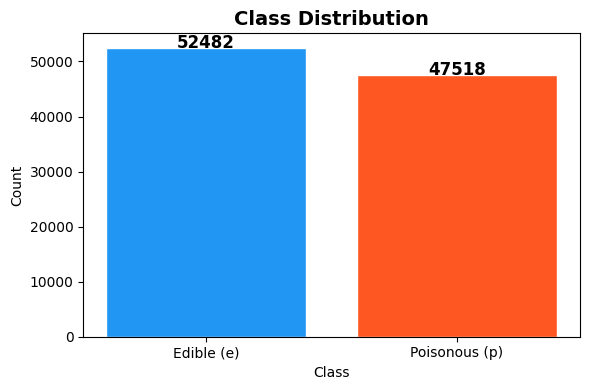

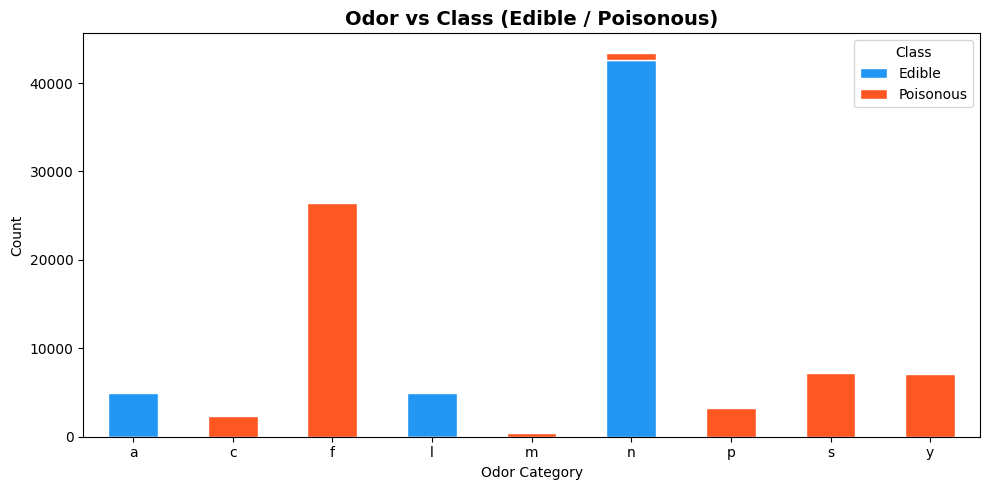

Top 20 strongest associations between categorical features (Cramér's V):
gill-attachment           - stalk-color-above-ring    : 0.0843
gill-attachment           - stalk-color-below-ring    : 0.0825
gill-attachment           - veil-color                : 0.0781
stalk-color-above-ring    - veil-color                : 0.0707
gill-attachment           - spore-print-color         : 0.0703
gill-attachment           - gill-color                : 0.0646
odor                      - gill-size                 : 0.0645
stalk-color-below-ring    - ring-number               : 0.0619
odor                      - ring-number               : 0.0617
stalk-color-above-ring    - ring-number               : 0.0616
gill-size                 - gill-color                : 0.0601
bruises                   - ring-type                 : 0.0591
odor                      - ring-type                 : 0.0578
ring-number               - ring-type                 : 0.0566
stalk-color-above-ring    - ring-type        

In [8]:
# ── 3. EXPLORATORY DATA ANALYSIS (EDA) ─────────────────────────────────────
print("\n🔍 Exploratory Data Analysis...")

# 3a. Check for missing / placeholder values
missing_mask = (df == "?")
cols_with_missing = missing_mask.sum()[missing_mask.sum() > 0]
print(f"   Columns with '?' values:")
for col, count in cols_with_missing.items():
    print(f"     • {col}: {count} ({count/len(df)*100:.1f}%)")

# 3b. Feature cardinality — how many unique values per feature
print("\n   Feature cardinality:")
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"     • {col}: {n_unique} unique values")

# 3c. Check if veil-type is constant (it is — only one value)
if df["veil-type"].nunique() == 1:
    print(f"\n   ⚠  'veil-type' has only 1 unique value → will be dropped (no info)")

    fig, ax = plt.subplots(figsize=(6, 4))
counts = df['class'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2196F3', '#FF5722'], edgecolor='white')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Edible (e)', 'Poisonous (p)'])

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df['odor'], df['class'])
ct.columns = ['Edible', 'Poisonous']
ct.plot(kind='bar', stacked=True, ax=ax, color=['#2196F3', '#FF5722'], edgecolor='white')
ax.set_title('Odor vs Class (Edible / Poisonous)', fontsize=14, fontweight='bold')
ax.set_xlabel('Odor Category')
ax.set_ylabel('Count')
ax.legend(title='Class')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import chi2_contingency

# ---- Cramér's V for categorical association ----
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    r, k = confusion.shape
    # avoid division issues if r or k == 1
    denom = n * (min(r - 1, k - 1) if min(r - 1, k - 1) > 0 else 1)
    return np.sqrt(chi2 / denom)

# ---- Compute top related feature pairs ----
features = [c for c in df.columns if c != "class"]

pairs = []
for a, b in combinations(features, 2):
    v = cramers_v(df[a], df[b])
    pairs.append((a, b, v))

pairs_sorted = sorted(pairs, key=lambda t: t[2], reverse=True)

print("Top 20 strongest associations between categorical features (Cramér's V):")
top_n = 20
for a, b, v in pairs_sorted[:top_n]:
    print(f"{a:25s} - {b:25s} : {v:.4f}")

In [9]:
# ── 4. DATA CLEANING & PREPROCESSING ───────────────────────────────────────
print("\n🧹 Preprocessing...")

# 4a. Replace '?' with NaN, then handle missing values
df.replace("?", np.nan, inplace=True)

# Strategy for stalk-root: replace with mode (most frequent value)
# WHY: 30% of values are missing — dropping rows would lose too much data.
#       Imputing with mode preserves the distribution for a categorical feature.
stalk_root_mode = df["stalk-root"].mode()[0]
print(f"   Imputing stalk-root with mode: '{stalk_root_mode}'")
df["stalk-root"].fillna(stalk_root_mode, inplace=True)

# 4b. Drop 'veil-type' — constant feature, adds no information
df.drop(columns=["veil-type"], inplace=True)
print("   Dropped 'veil-type' (constant column)")

# 4c. Encode the target variable
le_target = LabelEncoder()
y = le_target.fit_transform(df["class"])  # e=0, p=1
class_names = le_target.classes_
print(f"   Target encoded: {dict(zip(class_names, le_target.transform(class_names)))}")

# 4d. Separate features
X = df.drop(columns=["class"])
feature_names = X.columns.tolist()

# 4e. One-Hot Encode all categorical features
# WHY: Tree models can work with label encoding, but one-hot is safer
#       because it doesn't impose a false ordinal relationship.
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_encoded = encoder.fit_transform(X)
encoded_feature_names = encoder.get_feature_names_out(feature_names)

print(f"   After one-hot encoding: {X_encoded.shape[1]} features")


🧹 Preprocessing...
   Imputing stalk-root with mode: 'b'
   Dropped 'veil-type' (constant column)
   Target encoded: {'e': np.int64(0), 'p': np.int64(1)}
   After one-hot encoding: 115 features


In [10]:
# ── 5. TRAIN / TEST SPLIT ──────────────────────────────────────────────────
print("\n✂️  Splitting data...")

# Stratified split: preserves class ratio in both sets
# WHY: Ensures both train and test sets have ~52%/48% class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,       # 80/20 split
    random_state=42,      # Reproducibility
    stratify=y            # Preserve class balance
)

print(f"   Train: {X_train.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")
print(f"   Train class balance: {np.mean(y_train==0):.1%} edible, {np.mean(y_train==1):.1%} poisonous")
print(f"   Test  class balance: {np.mean(y_test==0):.1%} edible, {np.mean(y_test==1):.1%} poisonous")



✂️  Splitting data...
   Train: 80000 samples
   Test:  20000 samples
   Train class balance: 52.5% edible, 47.5% poisonous
   Test  class balance: 52.5% edible, 47.5% poisonous


In [11]:
# ── 6. MODEL TRAINING & COMPARISON ─────────────────────────────────────────
print("\n🏗️  Training models...")
print("-" * 70)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100,
                               use_label_encoder=False,
                               eval_metric="logloss",
                               random_state=42,
                               verbosity=0
                           ), # Re-run to update results
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Cross-validation on training set (no data leakage!)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    # Fit on full training set, predict on test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    # ROC-AUC (probability-based metric)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None

    results[name] = {
        "model": model,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_acc": test_acc,
        "auc": auc,
        "y_pred": y_pred,
    }

    print(f"   {name:25s}  |  CV: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}  |  "
          f"Test: {test_acc:.4f}  |  AUC: {auc:.4f}" if auc else
          f"   {name:25s}  |  CV: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}  |  "
          f"Test: {test_acc:.4f}")

print("-" * 70)



🏗️  Training models...
----------------------------------------------------------------------
   Logistic Regression        |  CV: 0.9999 ± 0.0001  |  Test: 0.9999  |  AUC: 1.0000
   Decision Tree              |  CV: 0.9999 ± 0.0001  |  Test: 1.0000  |  AUC: 1.0000
   Random Forest              |  CV: 1.0000 ± 0.0000  |  Test: 1.0000  |  AUC: 1.0000
   Gradient Boosting          |  CV: 0.9999 ± 0.0001  |  Test: 0.9999  |  AUC: 1.0000
   XGBoost                    |  CV: 1.0000 ± 0.0001  |  Test: 1.0000  |  AUC: 1.0000
----------------------------------------------------------------------


In [12]:
# ── 7. SELECT BEST MODEL ───────────────────────────────────────────────────
# Re-selecting best model to ensure consistency with current 'results' from previous cell
best_name = max(results, key=lambda k: results[k]["test_acc"])
best = results[best_name]
print(f"\n🏆 Best model: {best_name}")
print(f"   Test accuracy:  {best['test_acc']:.4f} ({best['test_acc']*100:.2f}%)")
print(f"   Cross-val mean: {best['cv_mean']:.4f} \u00b1 {best['cv_std']:.4f}")
if best["auc"]:
    print(f"   ROC-AUC:        {best['auc']:.4f}")

# Check target
if best["test_acc"] >= 0.979:
    print(f"\n   ✅ TARGET MET: {best['test_acc']*100:.2f}% \u2265 97.90%")
else:
    print(f"\n   ⚠  TARGET NOT MET: {best['test_acc']*100:.2f}% < 97.90%")


🏆 Best model: Random Forest
   Test accuracy:  1.0000 (100.00%)
   Cross-val mean: 1.0000 ± 0.0000
   ROC-AUC:        1.0000

   ✅ TARGET MET: 100.00% ≥ 97.90%


In [13]:
# ── 8. DETAILED EVALUATION ─────────────────────────────────────────────────
print("\n📊 Classification Report (best model):")
print(classification_report(y_test, best["y_pred"],
                            target_names=["edible", "poisonous"]))


📊 Classification Report (best model):
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00     10496
   poisonous       1.00      1.00      1.00      9504

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



📈 Generating plots...


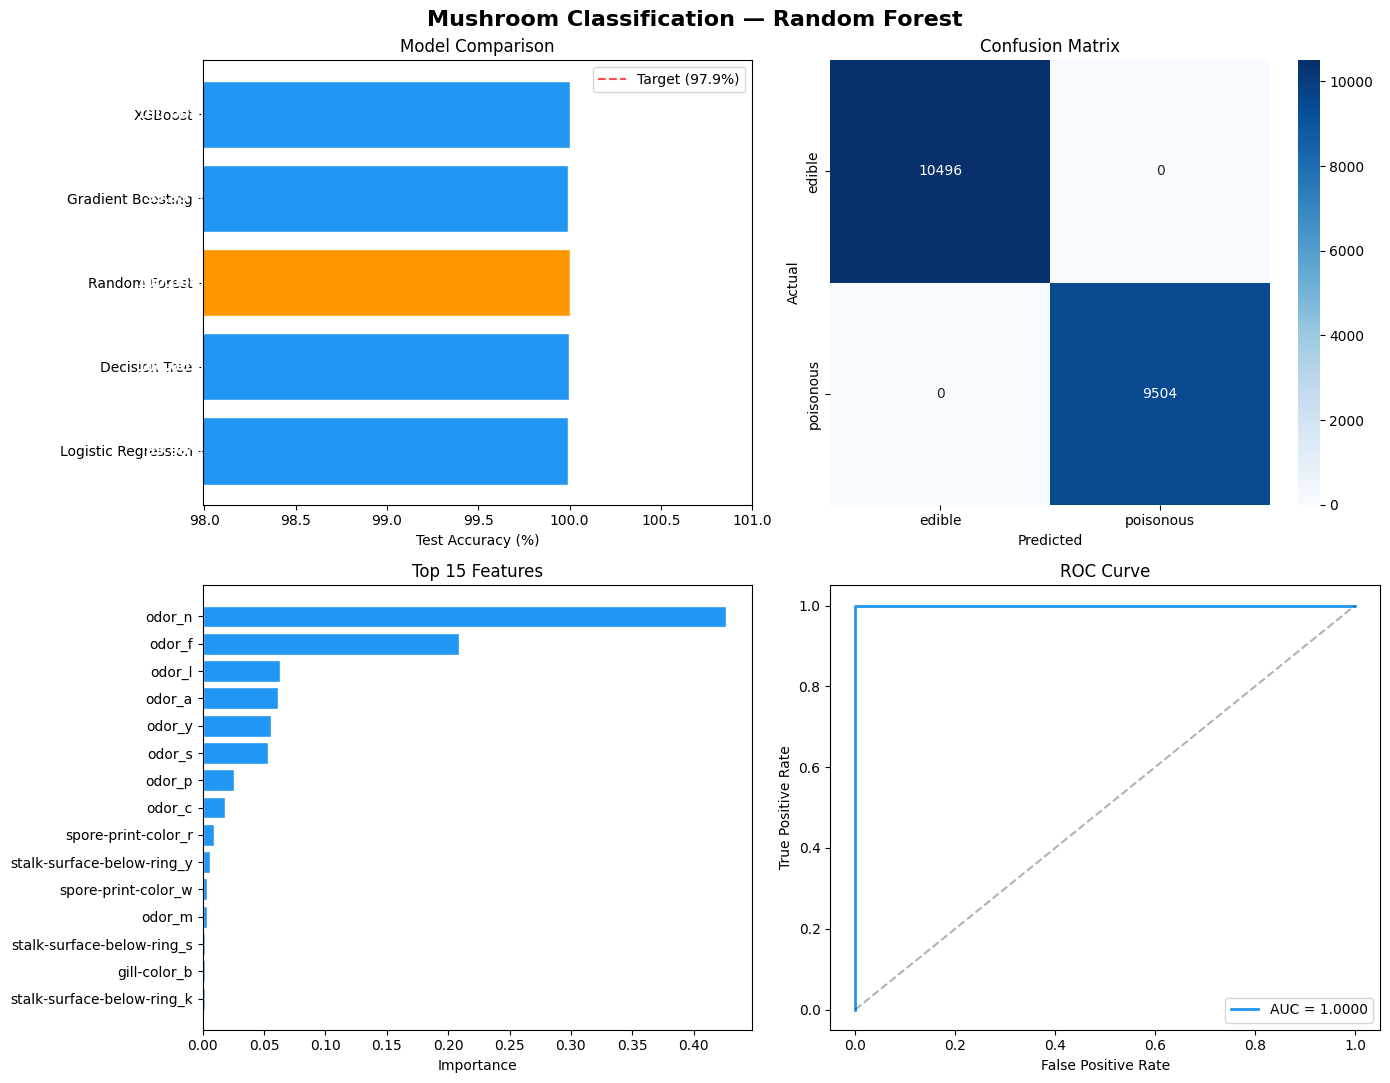

   Saved: mushroom_results.png


In [14]:
# ── 9. VISUALIZATIONS ──────────────────────────────────────────────────────
print("📈 Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f"Mushroom Classification — {best_name}", fontsize=16, fontweight="bold")

# 9a. Model comparison bar chart
ax = axes[0, 0]
model_names = list(results.keys())
test_accs = [results[m]["test_acc"] * 100 for m in model_names]
colors = ["#2196F3" if m != best_name else "#FF9800" for m in model_names]
bars = ax.barh(model_names, test_accs, color=colors, edgecolor="white")
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Model Comparison")
ax.axvline(x=97.9, color="red", linestyle="--", alpha=0.7, label="Target (97.9%)")
ax.legend()
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}%", va="center", ha="right", fontweight="bold", color="white")
ax.set_xlim(min(test_accs) - 2, 101)

# 9b. Confusion matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["edible", "poisonous"],
            yticklabels=["edible", "poisonous"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# 9c. Feature importance (top 15)
ax = axes[1, 0]
if hasattr(best["model"], "feature_importances_"):
    importances = best["model"].feature_importances_
    top_k = 15
    top_idx = np.argsort(importances)[-top_k:]
    ax.barh(
        [encoded_feature_names[i][:30] for i in top_idx],
        importances[top_idx],
        color="#2196F3", edgecolor="white"
    )
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_k} Features")
else:
    ax.text(0.5, 0.5, "N/A for this model", ha="center", va="center")

# 9d. ROC curve
ax = axes[1, 1]
if best["auc"]:
    y_prob = best["model"].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC = {best['auc']:.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()

plt.tight_layout()
plt.savefig("mushroom_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("   Saved: mushroom_results.png")

In [15]:
# ── 10. EXPERIMENT LOG ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  EXPERIMENT LOG (keep this for the Q&A!)")
print("=" * 70)
print(f"""
  Dataset:          UCI Mushroom Dataset (8,124 × 22)
  Task:             Binary classification (edible vs poisonous)
  Preprocessing:    - Replaced '?' in stalk-root with mode ('{stalk_root_mode}')
                    - Dropped 'veil-type' (constant, 1 unique value)
                    - One-hot encoded all 21 categorical features → {X_encoded.shape[1]} features
  Split:            80/20 stratified, random_state=42
  Models tested:    {', '.join(model_names)}
  Best model:       {best_name}
  Test accuracy:    {best['test_acc']*100:.2f}%
  Cross-val:        {best['cv_mean']*100:.2f}% ± {best['cv_std']*100:.2f}%
  AUC:              {f"{best['auc']:.4f}" if best['auc'] else 'N/A'}
  Target (97.9%):   {'✅ MET' if best['test_acc'] >= 0.979 else '⚠  NOT MET'}
""")

print("=" * 70)
print("  Done! Good luck at the hackathon 🍄")


  EXPERIMENT LOG (keep this for the Q&A!)

  Dataset:          UCI Mushroom Dataset (8,124 × 22)
  Task:             Binary classification (edible vs poisonous)
  Preprocessing:    - Replaced '?' in stalk-root with mode ('b')
                    - Dropped 'veil-type' (constant, 1 unique value)
                    - One-hot encoded all 21 categorical features → 115 features
  Split:            80/20 stratified, random_state=42
  Models tested:    Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost
  Best model:       Random Forest
  Test accuracy:    100.00%
  Cross-val:        100.00% ± 0.00%
  AUC:              1.0000
  Target (97.9%):   ✅ MET

  Done! Good luck at the hackathon 🍄


In [16]:
# ── CORRELATION ANALYSIS (Cramér's V) ──────────────────────────────────────
# Pearson correlation only works for numbers. Our features are all categorical,
# so we use Cramér's V to measure association between each feature and the target.

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V — correlation for categorical variables (0 to 1)"""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = len(x)
    min_dim = min(confusion.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Calculate correlation of each feature with the target (class)
print("FEATURE CORRELATION WITH TARGET (Cramér's V)")
print("=" * 55)
print(f"{'Feature':<30} {'Cramers V':>10}  {'Strength'}")
print("-" * 55)
correlations = {}
for col in df.columns:
    if col != "class":
        v = cramers_v(df[col], df["class"])
        correlations[col] = v

# Sort by correlation strength (highest first)
for col, v in sorted(correlations.items(), key=lambda x: x[1], reverse=True):
    if v >= 0.5:
        strength = "🔴 Strong"
    elif v >= 0.3:
        strength = "🟡 Moderate"
    else:
        strength = "⚪ Weak"
    print(f"   {col:<28} {v:>8.4f}    {strength}")

print("-" * 55)
print("\nCramér's V: 0 = no association, 1 = perfect association")
print("Strong features are the best predictors of edible vs poisonous")

FEATURE CORRELATION WITH TARGET (Cramér's V)
Feature                         Cramers V  Strength
-------------------------------------------------------
   odor                           0.9832    🔴 Strong
   spore-print-color              0.1022    ⚪ Weak
   gill-color                     0.0580    ⚪ Weak
   stalk-surface-below-ring       0.0561    ⚪ Weak
   ring-type                      0.0504    ⚪ Weak
   stalk-surface-above-ring       0.0472    ⚪ Weak
   gill-size                      0.0460    ⚪ Weak
   stalk-color-below-ring         0.0432    ⚪ Weak
   stalk-color-above-ring         0.0382    ⚪ Weak
   bruises                        0.0375    ⚪ Weak
   habitat                        0.0371    ⚪ Weak
   population                     0.0367    ⚪ Weak
   gill-spacing                   0.0297    ⚪ Weak
   stalk-root                     0.0272    ⚪ Weak
   cap-color                      0.0208    ⚪ Weak
   cap-shape                      0.0169    ⚪ Weak
   ring-number               

In [ ]:
# ── CRAMÉR'S V HEATMAP ──────────────────────────────────────────────────────
# Build a full feature × feature Cramér's V matrix and visualise it as a heatmap.

feature_cols = [c for c in df.columns if c != 'class']

# Build the symmetric matrix
n_feat = len(feature_cols)
cv_matrix = np.zeros((n_feat, n_feat))

for i, col_i in enumerate(feature_cols):
    for j, col_j in enumerate(feature_cols):
        if i == j:
            cv_matrix[i, j] = 1.0
        elif j > i:
            v = cramers_v(df[col_i], df[col_j])
            cv_matrix[i, j] = v
            cv_matrix[j, i] = v  # symmetric

import pandas as pd
cv_df = pd.DataFrame(cv_matrix, index=feature_cols, columns=feature_cols)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(cv_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

# Axis labels
ax.set_xticks(range(n_feat))
ax.set_yticks(range(n_feat))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

# Annotate each cell with the value
for i in range(n_feat):
    for j in range(n_feat):
        val = cv_matrix[i, j]
        color = 'white' if val > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, label="Cramér's V")
ax.set_title("Cramér's V Association Heatmap\n(feature × feature, categorical variables)",
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
print("Cramér's V: 0 = no association, 1 = perfect association")


Mushroom Classification — ML Pipeline